In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Import LabelEncoder to convert categorical text data into numbers
from sklearn.preprocessing import LabelEncoder
%matplotlib inline
# Load the dataset
df = pd.read_csv("final_internship_data.csv")

In [5]:
# Display the first 5 rows of the dataset
df.head()


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [6]:
# Display dataset information
# Shows column names, data types, and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [7]:
# Generate statistical summary for numerical columns
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358361,-1.265712,0.696740,-1.265755,0.696675,1.683428,13.510834,15.684206,6.268650,3.042008,2011.739132,385.279367,380.503657,363.843772,363.674038,355.991423,19.468775,0.297145
std,9.916617,0.206941,0.140909,0.205903,0.128997,1.307395,6.511571,8.681066,3.437815,1.949240,1.860889,2419.087483,2428.804740,2425.075903,2428.348683,2428.730839,367.299601,1.804548
min,-44.900000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341514,32.173712,17.100762,14.886989,7.147384,1.214550,-0.854721
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116970,-0.050442
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785649,38.304502,22.214815,22.417812,14.448699,3.890070,2.206769
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


In [8]:
# Check the shape of the dataset
# Displays number of rows and columns
print("Rows and Columns:", df.shape)

Rows and Columns: (500000, 26)


In [9]:
# Check for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates Removed")
print("Rows and Columns:", df.shape)


Duplicate Rows: 0
Duplicates Removed
Rows and Columns: (500000, 26)


In [10]:
# Check missing values in each column
df.isnull().sum()

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

In [11]:
df.dropna(inplace=True)
df.isnull().sum()

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             0
ewr_dist             0
lga_dist             0
sol_dist             0
nyc_dist             0
distance             0
bearing              0
dtype: int64

In [12]:
# Convert pickup_datetime column from object to datetime format
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
# df['week'] = df['pickup_datetime'].dt.isocalendar().week
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499995 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   User ID            499995 non-null  object        
 1   User Name          499995 non-null  object        
 2   Driver Name        499995 non-null  object        
 3   Car Condition      499995 non-null  object        
 4   Weather            499995 non-null  object        
 5   Traffic Condition  499995 non-null  object        
 6   key                499995 non-null  object        
 7   fare_amount        499995 non-null  float64       
 8   pickup_datetime    499995 non-null  datetime64[ns]
 9   pickup_longitude   499995 non-null  float64       
 10  pickup_latitude    499995 non-null  float64       
 11  dropoff_longitude  499995 non-null  float64       
 12  dropoff_latitude   499995 non-null  float64       
 13  passenger_count    499995 non-null  int64        

In [13]:
# Remove unnecessary columns that are not useful for analysis
df.drop(
    columns=[
        'User ID',
        'User Name',
        'Driver Name',
        'key'
    ],
    inplace=True
)

In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

original_df = pd.read_csv("final_internship_data.csv")

le = LabelEncoder()
le.fit(original_df['Car Condition'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Bad': 0, 'Excellent': 1, 'Good': 2, 'Very Good': 3}


In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

original_df = pd.read_csv("final_internship_data.csv")

le = LabelEncoder()
le.fit(original_df['Weather'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'cloudy': 0, 'rainy': 1, 'stormy': 2, 'sunny': 3, 'windy': 4}


In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

original_df = pd.read_csv("final_internship_data.csv")

le = LabelEncoder()
le.fit(original_df['Traffic Condition'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Congested Traffic': 0, 'Dense Traffic': 1, 'Flow Traffic': 2}


In [14]:
# Display unique values in categorical columns
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n{col}") 
    print(df[col].unique())
    


Car Condition
['Very Good' 'Excellent' 'Bad' 'Good']

Weather
['windy' 'cloudy' 'stormy' 'sunny' 'rainy']

Traffic Condition
['Congested Traffic' 'Flow Traffic' 'Dense Traffic']


In [15]:
encoder = LabelEncoder()

categorical_cols = [
    'Car Condition',
    'Weather',
    'Traffic Condition'
]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])
df.head()

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,3,4,0,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,1,0,2,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,0,2,0,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,3,2,2,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,0,2,0,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


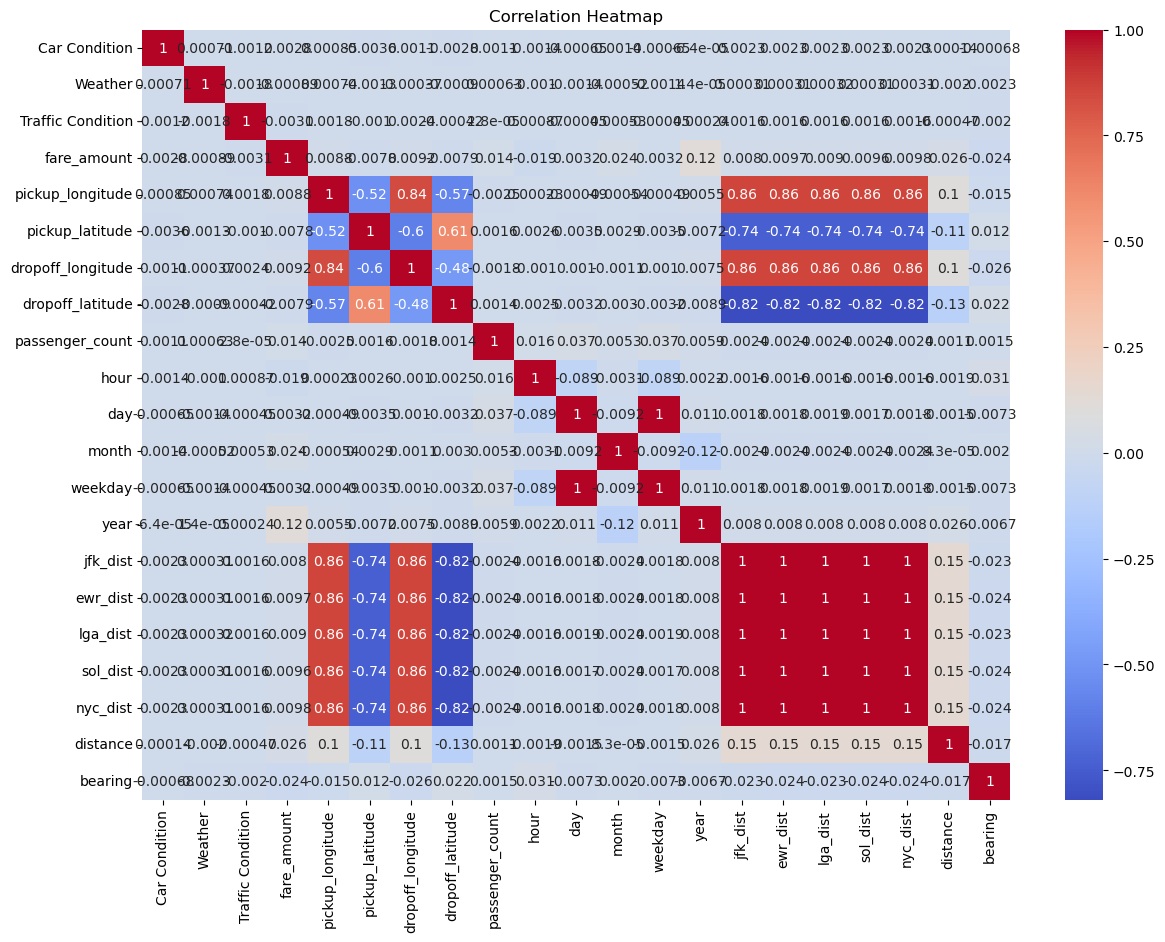

In [16]:
# Calculate correlation matrix between numerical features
corr = df.corr(numeric_only=True) 
plt.figure(figsize=(14,10)) 
sns.heatmap(corr, annot=True, cmap='coolwarm') 
plt.title("Correlation Heatmap")
plt.show()

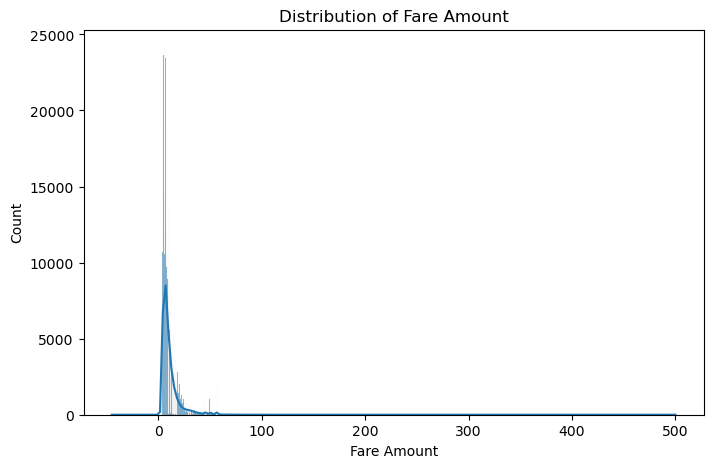

In [17]:
# Plot distribution of fare amount
plt.figure(figsize=(8,5))
sns.histplot(df['fare_amount'], kde=True) 
plt.title("Distribution of Fare Amount") 
plt.xlabel("Fare Amount") 
plt.show()

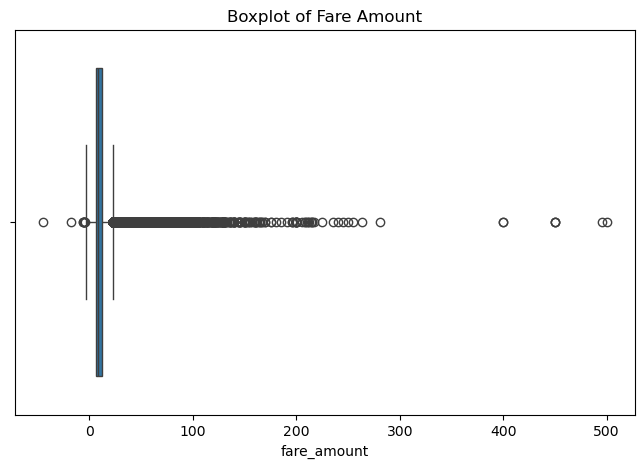

In [21]:
plt.figure(figsize=(8,5)) 
sns.boxplot(x=df['fare_amount'])
plt.title("Boxplot of Fare Amount")
plt.show()

In [22]:
# Remove outliers from the dataset
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75) 
IQR = Q3 - Q1 
lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR
df = df[ (df['fare_amount'] >= lower_bound) & (df['fare_amount'] <= upper_bound) ]

In [23]:
print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (456666, 22)


In [24]:
df.head()

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,3,4,0,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,1,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,1,0,2,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,1,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,0,2,0,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,2,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,3,2,2,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,1,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,0,2,0,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,1,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [25]:
# Save cleaned dataset to CSV file
df.to_csv("cleaned_uber_data.csv", index=False)

Q1) Is higher passenger count associated with higher fare?

Plot Choice

Scatter Plot

Why?

Because both passenger_count and fare_amount are numerical variables.

This plot shows whether rides with more passengers tend to have higher fares.



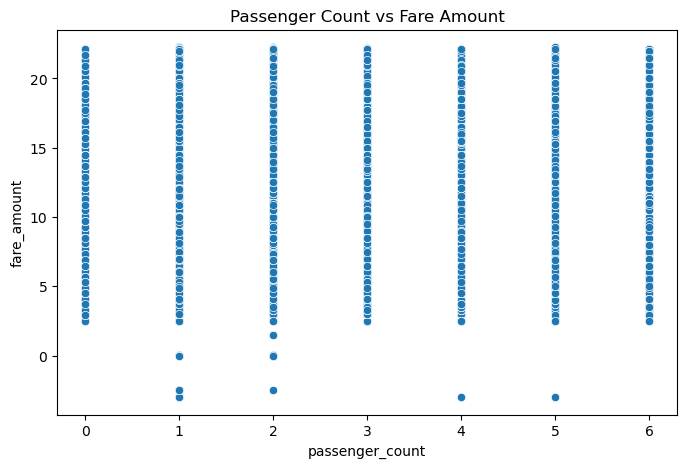

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='passenger_count',
    y='fare_amount',
    data=df
)

plt.title("Passenger Count vs Fare Amount")

plt.show()

There is no strong relationship between passenger count and fare amount. Most rides have similar fares regardless of the number of passengers.

Q2) Does car condition influence fare amount?

Plot Choice

Boxplot

Why?

Because Car Condition is categorical and fare_amount is numerical.

This plot compares fare distributions between different car conditions.

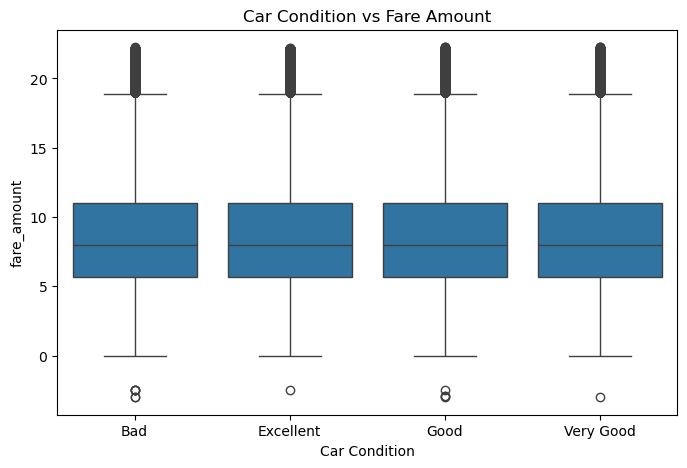

In [28]:
# Create a copy of the dataframe
plot_df = df.copy()

car_labels = {
    0: 'Bad',
    1: 'Excellent',
    2: 'Good',
    3: 'Very Good'
}

plot_df['Car Condition'] = plot_df['Car Condition'].map(car_labels)

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Car Condition',
    y='fare_amount',
    data=plot_df,
    order=['Bad', 'Excellent', 'Good', 'Very Good']
)

plt.title("Car Condition vs Fare Amount")
plt.show()

Car condition does not strongly influence fare amount, as all categories have very similar fare distributions.

Q3) At what hour are fares typically highest?

Plot Choice

Line Plot

Why?

Because hour is time-ordered numerical data.

This plot shows how average fares change throughout the day.

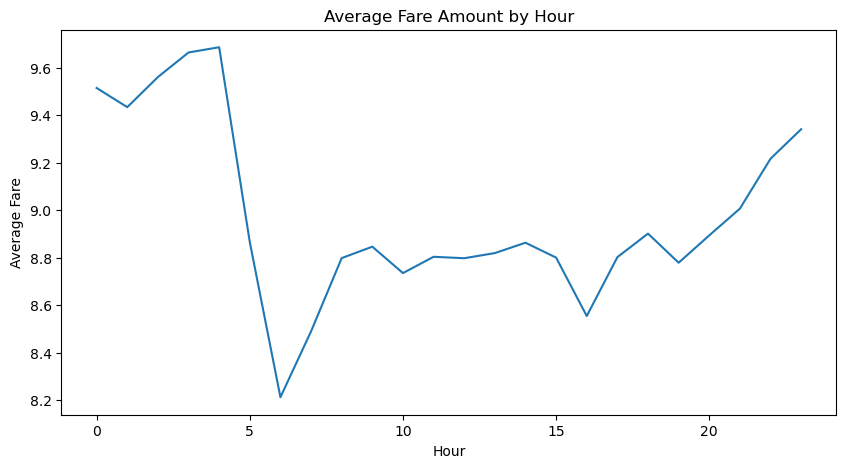

In [29]:
hourly_fare = df.groupby('hour')['fare_amount'].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_fare.index,
    y=hourly_fare.values
)

plt.title("Average Fare Amount by Hour")

plt.xlabel("Hour")

plt.ylabel("Average Fare")

plt.show()

Average fares tend to increase during peak traffic hours and late-night periods.

Q4) Does traffic condition affect fare amount?
Plot Choice

Boxplot

Why?

Because traffic condition is categorical while fare amount is numerical.

This plot helps determine whether heavy traffic leads to higher fares.

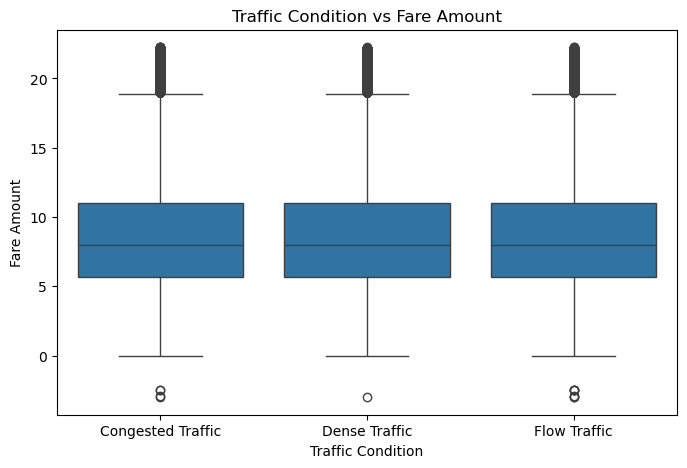

In [30]:
# Create a copy of the dataframe
plot_df = df.copy()

# Convert encoded values back to category names
traffic_labels = {
    0: 'Congested Traffic',
    1: 'Dense Traffic',
    2: 'Flow Traffic'
}

plot_df['Traffic Condition'] = plot_df['Traffic Condition'].map(traffic_labels)

# Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Traffic Condition',
    y='fare_amount',
    data=plot_df,
    order=['Congested Traffic', 'Dense Traffic', 'Flow Traffic']
)

plt.title("Traffic Condition vs Fare Amount")
plt.xlabel("Traffic Condition")
plt.ylabel("Fare Amount")

plt.show()

Traffic conditions show only a slight effect on fare amount, as the fare distributions across traffic categories are relatively similar.

Q5) Is distance the strongest predictor of fare amount?

Plot Choice

Scatter Plot

Why?

Because both variables are numerical.

This plot shows whether fare increases as trip distance increases.

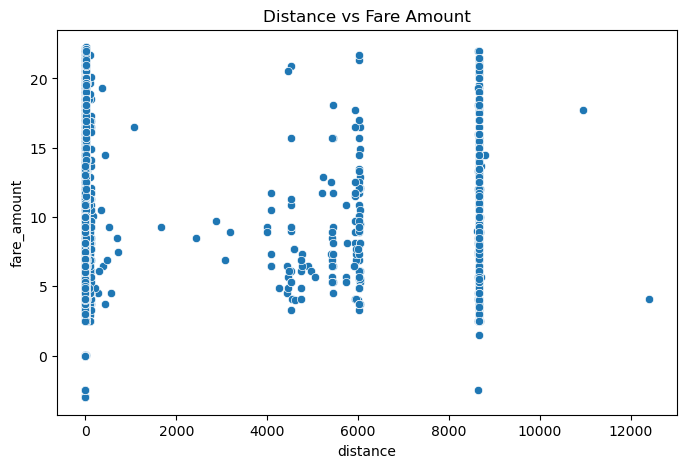

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='distance',
    y='fare_amount',
    data=df
)

plt.title("Distance vs Fare Amount")

plt.show()

There is a positive relationship between trip distance and fare amount. Longer trips usually result in higher fares.

Q6) At what time are ride requests most frequent?

Plot Choice

Count Plot

Why?

Because we want to count ride frequency across hours.

This plot identifies peak ride demand hours.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13948\1416926164.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('RdYlGn_r')


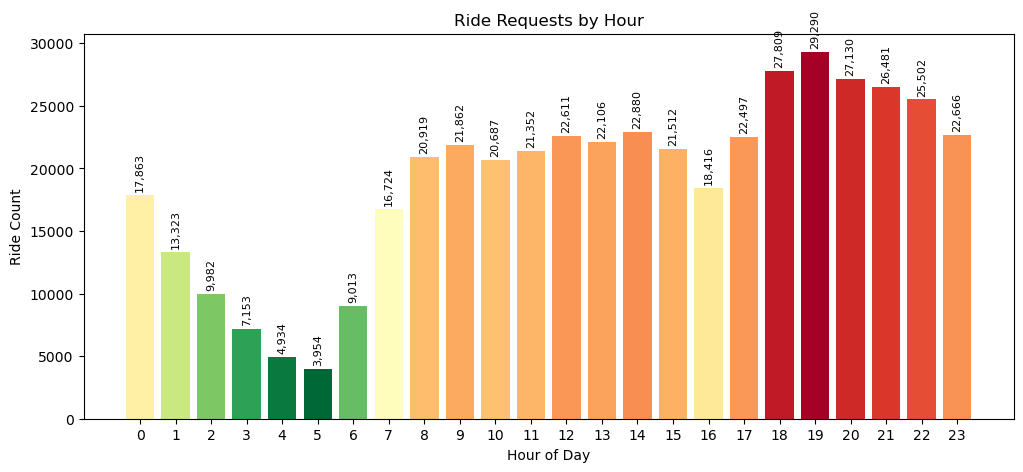

In [41]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Count rides by hour
hour_counts = df['hour'].value_counts().sort_index()

# Normalize counts to range [0,1]
norm = mcolors.Normalize(
    vmin=hour_counts.min(),
    vmax=hour_counts.max()
)

# Colormap: Green -> Yellow -> Red
cmap = cm.get_cmap('RdYlGn_r')

colors = cmap(norm(hour_counts.values))

plt.figure(figsize=(12,5))

bars = plt.bar(
    hour_counts.index,
    hour_counts.values,
    color=colors
)

# Add ride counts above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 300,
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90
    )

plt.title("Ride Requests by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Ride Count")
plt.xticks(range(24))

plt.show()

Ride requests are more frequent during peak hours, especially in the morning and evening.

Q7) Does weather condition influence trip distance?

Plot Choice

Boxplot

Why?

Because weather is categorical while distance is numerical.

This plot shows whether weather conditions affect trip distances.


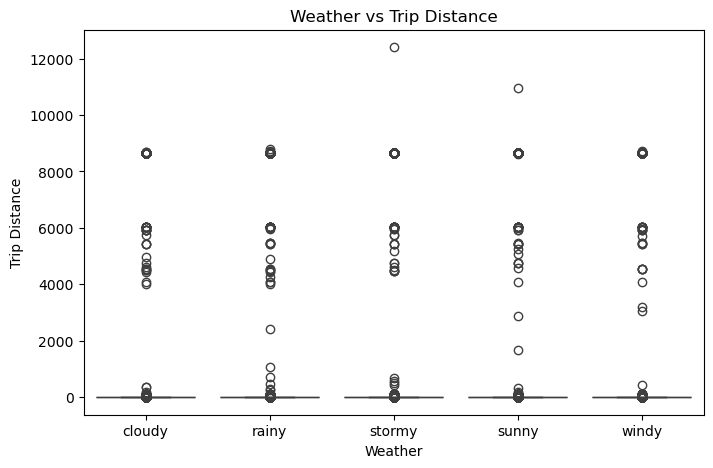

In [33]:
# Create a copy of the dataframe
plot_df = df.copy()

# Convert encoded values back to category names
weather_labels = {
    0: 'cloudy',
    1: 'rainy',
    2: 'stormy',
    3: 'sunny',
    4: 'windy'
}

plot_df['Weather'] = plot_df['Weather'].map(weather_labels)

# Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Weather',
    y='distance',
    data=plot_df,
    order=['cloudy', 'rainy', 'stormy', 'sunny', 'windy']
)

plt.title("Weather vs Trip Distance")
plt.xlabel("Weather")
plt.ylabel("Trip Distance")

plt.show()

Weather conditions do not appear to significantly affect trip distance, although there are several extreme distance outliers across all weather categories.

Q8) Are rides closer to airports more expensive?

Plot Choice

Scatter Plot

Why?

Because airport distance and fare amount are numerical variables.

This plot shows whether rides near airports tend to have higher fares.


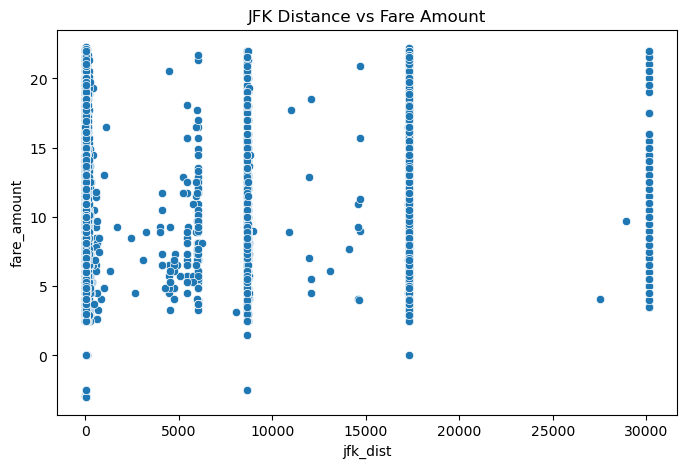

In [34]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='jfk_dist',
    y='fare_amount',
    data=df
)

plt.title("JFK Distance vs Fare Amount")

plt.show()

Rides that start closer to airports tend to have higher fares compared to rides farther away from airports.

Q9) Which weekday has the highest demand?

Suitable Plot:

Count Plot

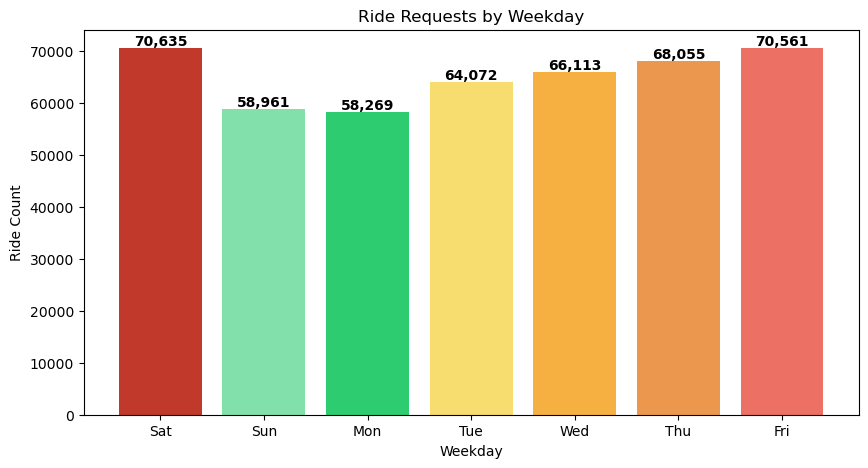

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# ترتيب الأيام
week_order = ['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri']

# عدد الرحلات لكل يوم
counts = df['weekday_name'].value_counts().reindex(week_order)

# ترتيب الأيام من الأقل إلى الأعلى
sorted_days = counts.sort_values()

# تدرج الألوان من الأخضر إلى الأحمر
color_map = {
    sorted_days.index[0]: '#2ECC71',  # Green (Lowest)
    sorted_days.index[1]: '#82E0AA',  # Light Green
    sorted_days.index[2]: '#F7DC6F',  # Yellow
    sorted_days.index[3]: '#F5B041',  # Orange
    sorted_days.index[4]: '#EB984E',  # Dark Orange
    sorted_days.index[5]: '#EC7063',  # Light Red
    sorted_days.index[6]: '#C0392B'   # Dark Red (Highest)
}

# الألوان حسب ترتيب العرض
colors = [color_map[day] for day in week_order]

plt.figure(figsize=(10,5))

ax = plt.bar(
    counts.index,
    counts.values,
    color=colors
)

# كتابة عدد الرحلات فوق كل عمود
for bar in ax:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 500,
        f'{int(height):,}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Ride Requests by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Ride Count")

plt.show()

The plot shows ride demand across different weekdays. The highest bars represent the days with the greatest number of ride requests